## Ranking Process Designs by the Operability Index

Author: Victor Alves - Carnegie Mellon University

When several candidate designs can do the same job, process operability gives a direct way to rank them: the Operability Index (OI) measures how much of the Desired Output Set (DOS) each design can actually reach {cite}`gazzaneo20`. ``rank_designs`` scores two or more process models against a shared DOS and orders them from most to least operable, either from the output perspective ($\mu(AOS \cap DOS)/\mu(DOS)$) or, by inverse mapping, from the input perspective ($\mu(DIS^* \cap AIS)/\mu(AIS)$).

This example compares two designs of a continuous stirred-tank reactor (CSTR) with consecutive reactions A $\rightarrow$ B $\rightarrow$ C {cite}`vinson00`: a compact reactor and a taller one of twice the volume. The inputs are the reactor radius $R$ and the dimensionless inverse temperature $1/RT$; the outputs are the reactant and intermediate concentrations $C_A$ and $C_B$. The question is which geometry better covers a desired $(C_A, C_B)$ window.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from opyrability import rank_designs

plt.rcParams['figure.dpi'] = 150

### Two CSTR designs

The reactor is described by the same steady-state model in both cases; the two designs differ only in the reactor height $H$, which sets the volume $V = \pi R^2 H$. The taller reactor has twice the volume at any given radius, so it converts more reactant. Both designs share the same Available Input Set (AIS) and are scored against the same DOS.

In [2]:
def cstr(u, H):
    """
    Steady-state CSTR with the consecutive reactions A -> B -> C.

    Solves the steady-state mass balance for the reactant concentration (the
    meaningful root of the resulting quadratic) and evaluates the intermediate.

    Parameters
    ----------
    u : array-like, shape (2,)
        Inputs [R, RT]: the reactor radius R and the dimensionless inverse
        temperature 1/RT.
    H : float
        Reactor height; the volume is pi * R**2 * H.

    Returns
    -------
    numpy.ndarray, shape (2,)
        Outputs [Ca, Cb]: the reactant and intermediate concentrations.
    """
    v0, Ca0 = 1.0, 1.0
    volume = np.pi * u[0] ** 2 * H
    k1, k2 = np.exp(-3.0 / u[1]), np.exp(-10.0 / u[1])
    a, b, c = volume * k1, v0 + volume * k2, -v0 * Ca0
    Ca = (-b + np.sqrt(b ** 2 - 4 * a * c)) / (2 * a)
    Cb = k1 * Ca ** 2 * volume / v0
    return np.array([Ca, Cb])


# Two designs, differing only in the reactor height H (and thus the volume).
designs = {'Compact reactor (H=1)': lambda u: cstr(u, H=1.0),
           'Tall reactor (H=2)':    lambda u: cstr(u, H=2.0)}

AIS_bounds = np.array([[0.25, 3.0],     # R: reactor radius
                       [1.0, 15.0]])    # 1/RT: dimensionless inverse temperature
DOS_bounds = np.array([[0.10, 0.40],    # Ca: reactant concentration
                       [0.25, 0.55]])   # Cb: intermediate concentration

### Ranking by the output-space OI

For each design, ``rank_designs`` maps the AIS forward to the Achievable Output Set (AOS), intersects it with the DOS, and reports the OI. It prints the ranked table and draws a bar chart of the OI of each design.

plot=False selected. The operability set is still returned as a polytopic region of general dimension.


plot=False selected. The operability set is still returned as a polytopic region of general dimension.


Design ranking by output-space Operability Index:
  1. Tall reactor (H=2)     OI =  90.13 %
  2. Compact reactor (H=1)  OI =  74.92 %


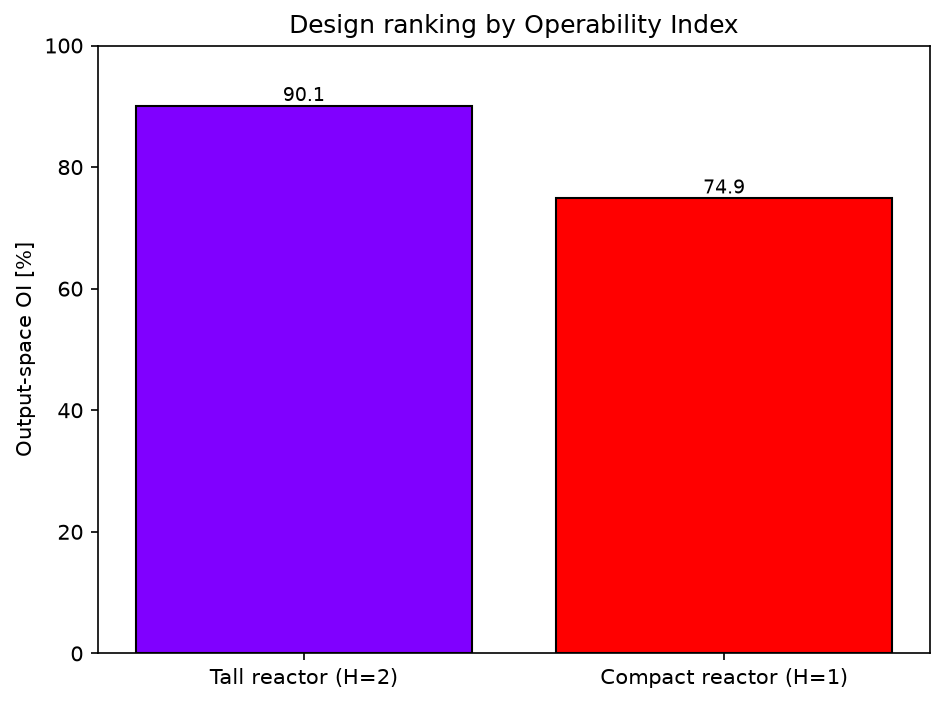

In [3]:
ranking = rank_designs(designs,
                       AIS_bound=AIS_bounds,
                       DOS_bound=DOS_bounds,
                       resolution=[12, 12],
                       perspective='outputs')

The taller reactor reaches a larger share of the desired $(C_A, C_B)$ region and is therefore ranked the more operable design. The returned ``ranking`` is a list of ``{'label', 'OI', 'region'}`` entries sorted from most to least operable, so the result is available for further analysis, not only for display.

The same call with ``perspective='inputs'`` instead inverts the DOS to the feasible desired input set and scores $\mu(DIS^* \cap AIS)/\mu(AIS)$, ranking the designs by the share of their input envelope that reaches the desired outputs.

### Conclusions

**Key Results:**

- ``rank_designs`` ranked two CSTR designs against a shared DOS by their Operability Index; the larger-volume reactor covers more of the desired output window and ranks higher.
- The ranking reuses the steady-state operability machinery (``multimodel_rep`` and ``OI_eval``), so it applies to any number of models that share the output space.

**Workflow Summary:**

1. Define the candidate designs as a dict of models.
2. Call ``rank_designs`` with a shared DOS (and per-design AIS if the input spaces differ).
3. Read off the ranked OI table and bar chart, or post-process the returned regions.